# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

[We've provided you with some commentary to guide your thinking as you complete this project. However, make sure to remove all the bracketed comments before submitting your project.]

[Before you dive into analyzing your data, explain for yourself the purpose of the project and actions you plan to take.]

[Please bear in mind that studying, amending, and analyzing data is an iterative process. It is normal to return to previous steps and correct/expand them to allow for further steps.]

## Initialization

In [1]:
from scipy import stats as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as factorial




## Load data

In [2]:
calls=pd.read_csv('/datasets/megaline_calls.csv')
internet=pd.read_csv('/datasets/megaline_internet.csv')
messages=pd.read_csv('/datasets/megaline_messages.csv')
plans=pd.read_csv('/datasets/megaline_plans.csv')
users=pd.read_csv('/datasets/megaline_users.csv')# Load the data files into different DataFrames
print(calls.info())
print()
print(internet.info())
print()
print(messages.info())
print()
print(plans.info())
print()
print(users.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Nul

## Prepare the data

In [3]:
#converting date columns to datetime
calls['call_date']=pd.to_datetime(calls['call_date'])
internet['session_date']=pd.to_datetime(internet['session_date'])
messages['message_date']=pd.to_datetime(messages['message_date'])
users['reg_date']=pd.to_datetime(users['reg_date'])
users['churn_date']=pd.to_datetime(users['churn_date'])


#roundup call duration (megaline seconds up to min)
calls['duration']=np.ceil(calls['duration'])




[The data for this project is split into several tables. Explore each one to get an initial understanding of the data. Do necessary corrections to each table if necessary.]

## Plans

In [4]:
print(plans.info())# Print the general/summary information about the plans' DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [5]:
print(plans)# Print a sample of data for plans

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

## Fix data

[Fix obvious issues with the data given the initial observations.]

In [6]:
#I am not seeing any obvious issues with the data upon initial review

## Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [7]:
#I do not see the need for any additional factors to add to the data

## Users

In [8]:
print(users.info())# Print the general/summary information about the users' DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


In [9]:
print(users)# Print a sample of data for users



     user_id first_name   last_name  age  \
0       1000   Anamaria       Bauer   45   
1       1001     Mickey   Wilkerson   28   
2       1002     Carlee     Hoffman   36   
3       1003   Reynaldo     Jenkins   52   
4       1004    Leonila    Thompson   40   
..       ...        ...         ...  ...   
495     1495      Fidel      Sharpe   67   
496     1496      Ariel    Shepherd   49   
497     1497      Donte     Barrera   49   
498     1498       Scot  Williamson   51   
499     1499      Shena     Dickson   37   

                                          city   reg_date      plan churn_date  
0        Atlanta-Sandy Springs-Roswell, GA MSA 2018-12-24  ultimate        NaT  
1              Seattle-Tacoma-Bellevue, WA MSA 2018-08-13      surf        NaT  
2         Las Vegas-Henderson-Paradise, NV MSA 2018-10-21      surf        NaT  
3                                Tulsa, OK MSA 2018-01-28      surf        NaT  
4              Seattle-Tacoma-Bellevue, WA MSA 2018-05-23      sur

[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix Data

[Fix obvious issues with the data given the initial observations.]

In [10]:
#I had noticed that I did not have churn_date converted to a datetime and it was returning NaN. I went back to my code from the earlier cell and added it. Other than that I do not currently see any obvious issues

### Enrich Data

[Add additional factors to the data if you believe they might be useful.]

In [11]:
#I do not believe that there is a need for any addtional factors yet

## Calls

In [12]:
print(calls.info())# Print the general/summary information about the calls' DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


In [13]:
print(calls)# Print a sample of data for calls



              id  user_id  call_date  duration
0        1000_93     1000 2018-12-27       9.0
1       1000_145     1000 2018-12-27      14.0
2       1000_247     1000 2018-12-27      15.0
3       1000_309     1000 2018-12-28       6.0
4       1000_380     1000 2018-12-30       5.0
...          ...      ...        ...       ...
137730  1499_199     1499 2018-11-21       9.0
137731  1499_200     1499 2018-10-20      11.0
137732  1499_201     1499 2018-09-21       9.0
137733  1499_202     1499 2018-10-10       1.0
137734  1499_203     1499 2018-12-29      14.0

[137735 rows x 4 columns]


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [14]:
#already fixed duration rounding issue. no additional issues in initial observation.

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [15]:
calls['month']=calls['call_date'].dt.month # added month to the date. no additional data needed

## Messages

In [16]:
print(messages.info())# Print the general/summary information about the messages' DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


In [17]:
print(messages)# Print a sample of data for messages



             id  user_id message_date
0      1000_125     1000   2018-12-27
1      1000_160     1000   2018-12-31
2      1000_223     1000   2018-12-31
3      1000_251     1000   2018-12-27
4      1000_255     1000   2018-12-26
...         ...      ...          ...
76046  1497_526     1497   2018-12-24
76047  1497_536     1497   2018-12-24
76048  1497_547     1497   2018-12-31
76049  1497_558     1497   2018-12-24
76050  1497_613     1497   2018-12-23

[76051 rows x 3 columns]


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [18]:
#no additional issues noted in initial review

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [19]:
messages['month']=messages['message_date'].dt.month #added month
print(messages)

             id  user_id message_date  month
0      1000_125     1000   2018-12-27     12
1      1000_160     1000   2018-12-31     12
2      1000_223     1000   2018-12-31     12
3      1000_251     1000   2018-12-27     12
4      1000_255     1000   2018-12-26     12
...         ...      ...          ...    ...
76046  1497_526     1497   2018-12-24     12
76047  1497_536     1497   2018-12-24     12
76048  1497_547     1497   2018-12-31     12
76049  1497_558     1497   2018-12-24     12
76050  1497_613     1497   2018-12-23     12

[76051 rows x 4 columns]


## Internet

In [20]:
print(internet.info())# Print the general/summary information about the internet DataFrame



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


In [21]:
print(internet)# Print a sample of data for the internet traffic



              id  user_id session_date  mb_used
0        1000_13     1000   2018-12-29    89.86
1       1000_204     1000   2018-12-31     0.00
2       1000_379     1000   2018-12-28   660.40
3       1000_413     1000   2018-12-26   270.99
4       1000_442     1000   2018-12-27   880.22
...          ...      ...          ...      ...
104820  1499_215     1499   2018-10-20   218.06
104821  1499_216     1499   2018-12-30   304.72
104822  1499_217     1499   2018-09-22   292.75
104823  1499_218     1499   2018-12-07     0.00
104824  1499_219     1499   2018-12-24   758.31

[104825 rows x 4 columns]


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [22]:
#no obvious issues remaining with the data upon initial review

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [23]:
internet['month']=internet['session_date'].dt.month #added month
print(internet)

              id  user_id session_date  mb_used  month
0        1000_13     1000   2018-12-29    89.86     12
1       1000_204     1000   2018-12-31     0.00     12
2       1000_379     1000   2018-12-28   660.40     12
3       1000_413     1000   2018-12-26   270.99     12
4       1000_442     1000   2018-12-27   880.22     12
...          ...      ...          ...      ...    ...
104820  1499_215     1499   2018-10-20   218.06     10
104821  1499_216     1499   2018-12-30   304.72     12
104822  1499_217     1499   2018-09-22   292.75      9
104823  1499_218     1499   2018-12-07     0.00     12
104824  1499_219     1499   2018-12-24   758.31     12

[104825 rows x 5 columns]


## Study plan conditions

[It is critical to understand how the plans work, how users are charged based on their plan subscription. So, we suggest printing out the plan information to view their conditions once again.]

In [24]:
print(plans)# Print out the plan conditions and make sure they are clear for you



   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [25]:
# Calculate the number of calls made by each user per month. Save the result.
calls_grouped=calls.groupby(['user_id','month']).agg({'id':'count'}).reset_index()
calls_grouped=calls_grouped.rename(columns={'id': 'calls_made'})



In [26]:
# Calculate the amount of minutes spent by each user per month. Save the result.
calls_grouped_2=calls.groupby(['user_id','month']).agg({'duration':'sum'}).reset_index()
calls_grouped_2=calls_grouped_2.rename(columns={'duration':'total_minutes'})



In [27]:
# Calculate the number of messages sent by each user per month. Save the result.
messages_grouped=messages.groupby(['user_id', 'month']).agg({'id': 'count'}).reset_index()
messages_grouped=messages_grouped.rename(columns={'id': 'messages_sent'})




In [28]:
# Calculate the volume of internet traffic used by each user per month. Save the result.
internet_grouped=internet.groupby(['user_id','month']).agg({'mb_used':'sum'}).reset_index()
internet_grouped=internet_grouped.rename(columns={'mb_used':'total_mb_used'})

[Put the aggregate data together into one DataFrame so that one record in it would represent what an unique user consumed in a given month.]

In [29]:
# Merge the data for calls, minutes, messages, internet based on user_id and month
megaline_results = calls_grouped.merge(calls_grouped_2, on=['user_id','month'], how='outer')
# Add messages
megaline_results = megaline_results.merge(messages_grouped, on=['user_id','month'], how='outer')
# Add internet
megaline_results = megaline_results.merge(internet_grouped, on=['user_id','month'], how='outer')
megaline_results = megaline_results.fillna(0)


In [30]:
# Add the plan information
megaline_results=megaline_results.merge(users[['user_id','plan']],on='user_id')
print(megaline_results.info())
print(megaline_results.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        2293 non-null   int64  
 1   month          2293 non-null   int64  
 2   calls_made     2293 non-null   float64
 3   total_minutes  2293 non-null   float64
 4   messages_sent  2293 non-null   float64
 5   total_mb_used  2293 non-null   float64
 6   plan           2293 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 143.3+ KB
None
   user_id  month  calls_made  total_minutes  messages_sent  total_mb_used  \
0     1000     12        16.0          124.0           11.0        1901.47   
1     1001      8        27.0          182.0           30.0        6919.15   
2     1001      9        49.0          315.0           44.0       13314.82   
3     1001     10        65.0          393.0           53.0       22330.49   
4     1001     11        64.0          

[Calculate the monthly revenue from each user (subtract the free package limit from the total number of calls, text messages, and data; multiply the result by the calling plan value; add the monthly charge depending on the calling plan). N.B. This might not be as trivial as just a couple of lines given the plan conditions! So, it's okay to spend some time on it.]

In [31]:
print(megaline_results.columns.tolist())

['user_id', 'month', 'calls_made', 'total_minutes', 'messages_sent', 'total_mb_used', 'plan']


In [32]:
#first merge the plans
megaline_results=megaline_results.merge(plans, left_on='plan', right_on='plan_name')
print(megaline_results.columns.tolist())

['user_id', 'month', 'calls_made', 'total_minutes', 'messages_sent', 'total_mb_used', 'plan', 'messages_included', 'mb_per_month_included', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'plan_name']


In [33]:
# Calculate the monthly revenue for each user

#Calculate the extra usage and revenue 
megaline_results['extra_minutes']= np.maximum(0, megaline_results['total_minutes'] - megaline_results['minutes_included'])
megaline_results['extra_messages']= np.maximum(0, megaline_results['messages_sent'] - megaline_results['messages_included'])

# Calculate extra GB (keep the loop for this part only)
megaline_results['extra_gb']= 0
for i in range(len(megaline_results)):
    if megaline_results.loc[i,'total_mb_used'] > megaline_results.loc[i,'mb_per_month_included']:
        extra_mb = megaline_results.loc[i,'total_mb_used'] - megaline_results.loc[i,'mb_per_month_included']
        megaline_results.loc[i,'extra_gb'] = np.ceil(extra_mb/1024)

# Calculate final revenue
megaline_results['revenue']=(megaline_results['usd_monthly_pay'] +
                            megaline_results['extra_minutes'] * megaline_results['usd_per_minute'] +
                            megaline_results['extra_messages'] * megaline_results['usd_per_message'] +
                            megaline_results['extra_gb'] * megaline_results['usd_per_gb'])

## Study user behaviour

[Calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. Draw useful plots to help the understanding. Given that the main task is to compare the plans and decide on which one is more profitable, the statistics and the plots should be calculated on a per-plan basis.]

[There are relevant hints in the comments for Calls but they are not provided for Messages and Internet though the principle of statistical study is the same for them as for Calls.]

### Calls

In [34]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plat to visualize it.
behavior= megaline_results.groupby('plan').agg({'total_minutes': 'mean',
                                               'messages_sent': 'mean',
                                               'total_mb_used': 'mean',
                                               'revenue': ['mean','median']}).round(2)
print(behavior)


         total_minutes messages_sent total_mb_used revenue       
                  mean          mean          mean    mean median
plan                                                             
surf            428.75         31.16      16558.28   60.71  40.36
ultimate        430.45         37.55      17214.70   72.31  70.00


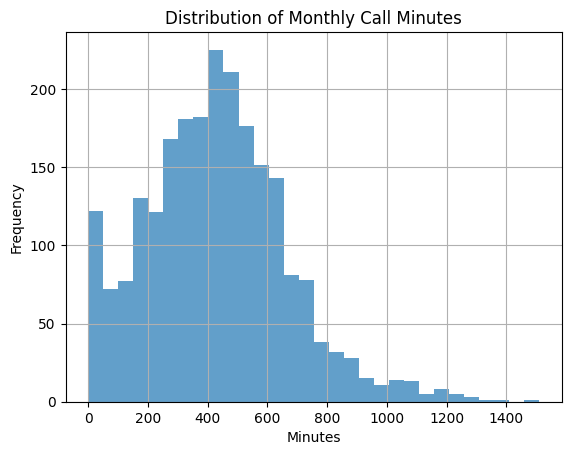

In [35]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.
megaline_results['total_minutes'].hist(bins=30, alpha=0.7)
plt.title('Distribution of Monthly Call Minutes')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()


[Calculate the mean and the variable of the call duration to reason on whether users on the different plans have different behaviours for their calls.]

In [36]:
# Calculate the mean and the variance of the monthly call duration
mean_duration=megaline_results['total_minutes'].mean()
variance_duration=megaline_results['total_minutes'].var()
print('Mean of Monthly Call Duration:', round(mean_duration,2))
print('Variance of Monthly Call Duration:', round(variance_duration,2))


Mean of Monthly Call Duration: 429.28
Variance of Monthly Call Duration: 55847.18


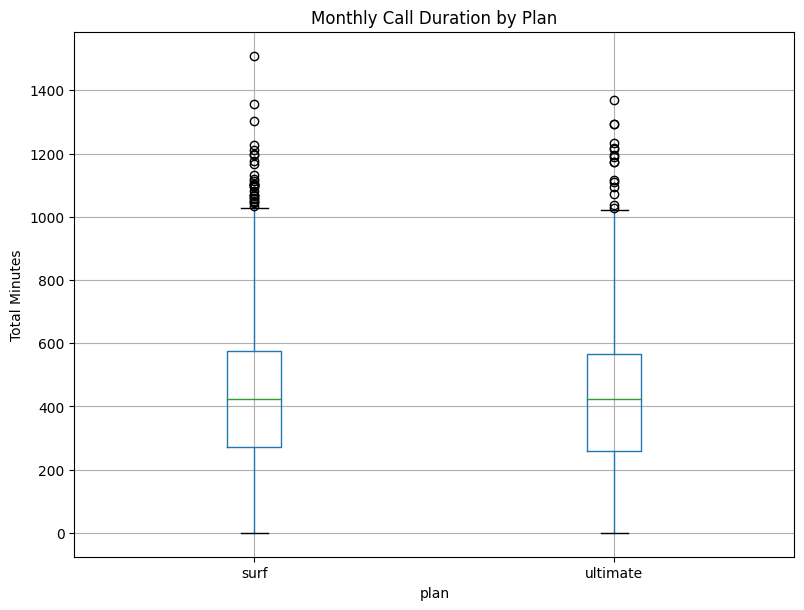

In [37]:
# Plot a boxplot to visualize the distribution of the monthly call duration
megaline_results.boxplot(column='total_minutes', by='plan', figsize=(9,7))
plt.title('Monthly Call Duration by Plan')
plt.suptitle('')
plt.ylabel('Total Minutes')
plt.show()


[Formulate conclusions on how the users behave in terms of calling. Is their behaviour different between the plans?]

### Messages

In [38]:
# Compare the number of messages users of each plan tend to send each month
print('Average messages sent per plan:')
print(megaline_results.groupby('plan')['messages_sent'].mean().round(2))


Average messages sent per plan:
plan
surf        31.16
ultimate    37.55
Name: messages_sent, dtype: float64


In [39]:
# Compare the amount of internet traffic consumed by users per plan
print('Average MB Used per plan')
print(megaline_results.groupby('plan')['total_mb_used'].mean().round(2))


Average MB Used per plan
plan
surf        16558.28
ultimate    17214.70
Name: total_mb_used, dtype: float64


From what I am seeing. users on the ultimate plan tend to text on average slightly more than on the surf plan. 

[Formulate conclusions on how the users behave in terms of messaging. Is their behaviour different between the plans?]

### Internet

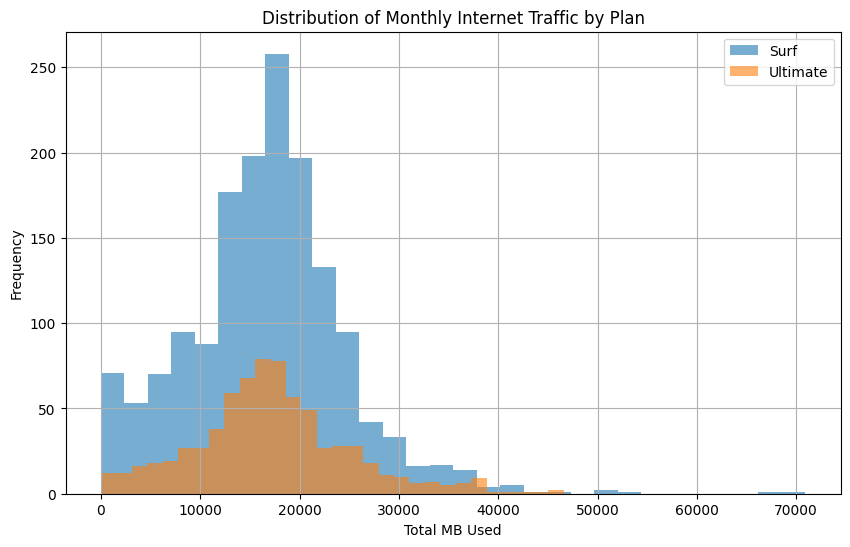

In [40]:
#shwoing the difference between surf and ultimate plans 
plt.figure(figsize=(10,6))
megaline_results[megaline_results['plan']=='surf']['total_mb_used'].hist(alpha=.6, label='Surf',bins=30)
megaline_results[megaline_results['plan']=='ultimate']['total_mb_used'].hist(alpha=.6, label='Ultimate', bins=30)
plt.legend()
plt.title('Distribution of Monthly Internet Traffic by Plan')
plt.xlabel('Total MB Used')
plt.ylabel('Frequency')
plt.show()

In [41]:
total_users_per_plan=megaline_results.groupby('plan')['total_mb_used'].count()
print('Total Number of Internet Users per Plan')
print(total_users_per_plan)

Total Number of Internet Users per Plan
plan
surf        1573
ultimate     720
Name: total_mb_used, dtype: int64


[Formulate conclusions on how the users tend to consume the internet traffic? Is their behaviour different between the plans?]

Based on the data it appears that there is a direct correlation to the number of users and the amount of times that internet is used. The instances show that there are more total usages by the Surf plan than the users on the Ultimate plan. However those on the Ultimate plan tend to consume higher amounts per plan than those on the Surf plan. It seems that those who have the Ultimate plan are more freely using their internet.

## Revenue

[Likewise you have studied the user behaviour, statistically describe the revenue between the plans.]

In [42]:
print("Revenue statistics by plan:")
print(megaline_results.groupby('plan')['revenue'].agg(['mean', 'median']).round(2))

Revenue statistics by plan:
           mean  median
plan                   
surf      60.71   40.36
ultimate  72.31   70.00


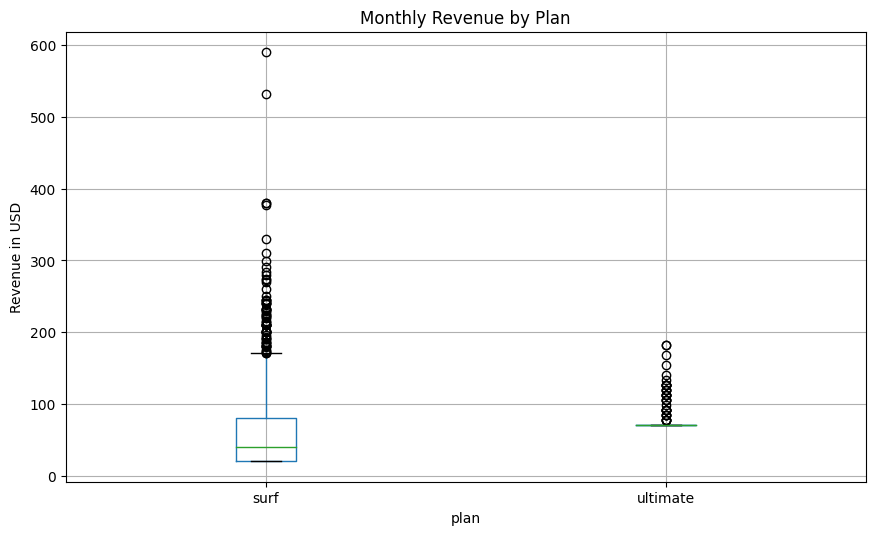

In [43]:
megaline_results.boxplot(column='revenue', by='plan', figsize=(10,6))
plt.title('Monthly Revenue by Plan')
plt.suptitle('')
plt.ylabel('Revenue in USD')
plt.show()

Based on the data, the Ultimate plan generates more revenue. This is likely due to the base cost. However due to the higher overage charges that are experienced in the Surf plan, the gap narrows significantly.

[Formulate conclusions about how the revenue differs between the plans.]

## Test statistical hypotheses

[Test the hypothesis that the average revenue from users of the Ultimate and Surf calling plans differs.]

[Formulate the null and the alternative hypotheses, choose the statistical test, decide on the alpha value.]

H0- Null hypothosis: The average revenue from the surf plan is equal to the average revenue from the ultimate plan. 
H1- Alternative hypothosis: The average revenue from the surf plan is different to the ultimate plan. 

Reason for using this test: Megaline's marketing group is looking to know which plan they should focus their resources on. In order to do so we need to determine which of the plans is going to be more profitable. This is the main question that Megaline is looking to answer.

In [44]:
# Test the hypotheses
print('Test 1: Surf Vs Ultimate Revenue')
surf_revenue=megaline_results[megaline_results['plan']=='surf']['revenue']
ultimate_revenue=megaline_results[megaline_results['plan']=='ultimate']['revenue']
alpha=.05
results1=st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)
print('p-value:', results1.pvalue)
if results1.pvalue < alpha:
    print('We reject the null hypothosis: There is a significant difference in average revenue')
else:
    print('We cant reject the null hypothosis: There is not a significant difference in average revenue')
    


Test 1: Surf Vs Ultimate Revenue
p-value: 3.1703905481135734e-15
We reject the null hypothosis: There is a significant difference in average revenue


[Test the hypothesis that the average revenue from users in the NY-NJ area is different from that of the users from the other regions.]

[Formulate the null and the alternative hypotheses, choose the statistical test, decide on the alpha value.]

H0- Null Hypothosis: The average revenue generated from plans based in the NY-NJ area is equal to the average revenue generated in other regions. 
H1- Alternative hypothisis: The average revenue generated from plans based in the NY-NJ region differs from other regions.

reason for the test: This is primarily a follow up test to see if there is any identifying differences due to geographical location. This can indicate whether or not there should be different marketing plans per region rather than on a national scale. It can also indicate if the data is skewed towards one region which we could then do further testing to see how all regions are averaging. 

In [45]:
#add city to megaline_results data frame
megaline_results=megaline_results.merge(users[['user_id', 'city']],on='user_id')
# Test the hypotheses

print('Test 2: NY-NJ Vs Remaining Regions')

megaline_results['region']='Other'
for i in range(len(megaline_results)):
    if 'NY-NJ' in str(megaline_results.loc[i, 'city']):
        megaline_results.loc[i, 'region']='NY-NJ'
ny_nj_revenue= megaline_results[megaline_results['region']=='NY-NJ']['revenue']
other_revenue=megaline_results[megaline_results['region']=='Other']['revenue']

results2=st.ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)
print('p-value:', results2.pvalue)
if results2.pvalue < alpha:
    print('We reject the null hypothosis: There is a significant difference of revenue')
else:
    print('We cant reject the null hypothosis: there is not a significant difference of revenue')


Test 2: NY-NJ Vs Remaining Regions
p-value: 0.033525615885300314
We reject the null hypothosis: There is a significant difference of revenue


## General conclusion

[List your important conclusions in this final section, make sure they cover all those important decisions (assumptions) that you've made and that led you to the way you processed and analyzed the data.]

Final conclusion:


1: User Behavior
- Ultimate plan users use more minutes, messages, and by far more internet data per user
- Ultimate users are definitely higher volume users overall
2: Revenue Analysis:
- The Ultimate plan generates more monthly revenue on average than the Surf plan does.
- According to the ttest results, the difference in revenue seems to be significantly different
Business Recommendation:

The ultimate plan is considerably more profitable than the surf plan. Due to this I recommend that the advertising budget be focused on advertising the ultimate plan. 